In [15]:
import logging
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as patches

import sys
E9path = Path("C:/", "Users", "ken92", "Documents", "Studies", "E5", "simulation", "E9_simulations")
sys.path.insert(1, str(E9path))
import E9_fn.thermodynamics as thmdy
from E9_fn import util
from E9_fn.tight_binding import E9tb
from projects.flat_band_cooling import helper_fns as hpfn

logpath = '' # '' if not logging to a file
loglevel = logging.INFO
logroot = logging.getLogger()
list(map(logroot.removeHandler, logroot.handlers))
list(map(logroot.removeFilter, logroot.filters))
logging.basicConfig(filename = logpath, level = loglevel)

In [16]:
lattice_str = "kagome"
lattice_len = 11
lattice_dim = (lattice_len, lattice_len)
overwrite_param = {}
# overwrite_param = {"sublat_offsets": [0., 0., 0., 15.]}
tb_params = E9tb.get_model_params(lattice_str, overwrite_param = overwrite_param)
my_tb_model = E9tb.tbmodel_2D(lat_dim = lattice_dim, **tb_params)
H_bare = my_tb_model.H

# Add offset to the bare model
sys_len = 0
sys_range = ((lattice_len - sys_len) // 2, (lattice_len + sys_len) // 2)
n_sys = sys_len**2
V_rsv_offset = 0.
# Find what unit cells are in the reservoir by excluding the unit cells in the system
sys_natural_uc_ind = set([(ii, jj) for jj in range(my_tb_model.lat_dim[1]) if sys_range[0] <= jj and jj < sys_range[1]
                                    for ii in range(my_tb_model.lat_dim[0]) if sys_range[0] <= ii and ii < sys_range[1]])
rsv_natural_uc_ind = set([(ii, jj) for jj in range(my_tb_model.lat_dim[1])
                                    for ii in range(my_tb_model.lat_dim[0])])
rsv_natural_uc_ind -= sys_natural_uc_ind
rsv_natural_uc_ind = np.array(list(rsv_natural_uc_ind))
logging.debug(rsv_natural_uc_ind)
rsv_ind = np.hstack(
    [my_tb_model.get_reduced_index(rsv_natural_uc_ind[:,0], rsv_natural_uc_ind[:,1], k)
        for k in range(my_tb_model.n_basis)])

H_offset = np.zeros_like(H_bare)
H_offset[rsv_ind, rsv_ind] = V_rsv_offset
H_total = H_bare + H_offset

In [18]:
CLS_pos_list = [(0, 4, 2), (0, 7, 2),
                (1, 8, 2),
                (2, 2, 2),
                (4, 4, 2),
                (5, 1, 2), (5, 5, 2), (5, 7, 2),
                (7, 1, 2), (7, 3, 2)] # the "reduced index" of the lower corner of hexagons
def plot_kag_CLS(ax, tb_model: E9tb.tbmodel_2D, pos):
    i, j, k = pos
    if k != 2: raise(ValueError("wrong CLS position (it's the bottom site)"))
    all_corners = [(i, j, 2), (i, j, 1), (i + 1, j, 0),
                   (i + 1, j, 2), (i, j + 1, 1), (i, j + 1, 0)]
    ac_roll = all_corners[1::] + [all_corners[0]]
    filled_pos = all_corners[::2]

    CLS_dict = {"color": "blue", "linewidth": 3}
    site1_dict = {"color": "blue", "edgecolors": "blue", "linewidth": 2}
    site2_dict = {"color": "white", "edgecolors": "blue", "linewidth": 2}
    for p1, p2 in zip(all_corners, ac_roll):
        pos1 = tb_model.get_lat_pos(p1)
        pos2 = tb_model.get_lat_pos(p2)
        ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], **CLS_dict)
        if p1 in filled_pos:
            ax.scatter(*pos1, **site1_dict, zorder = 100)
        else:
            ax.scatter(*pos1, **site2_dict, zorder = 100)


In [34]:
sys_bd_ind_list = [(6.7, 5, 2), (5, 6.7, 1), (3.3, 6.2, 2), (3.3, 2.7, 2), (6.7, 2.7, 2)]
sys_bd_list = [my_tb_model.get_lat_pos(p) for p in sys_bd_ind_list]
sys_bd_roll = sys_bd_list[1::] + [sys_bd_list[0]]
sys_dict = {"facecolor": "red",
            "lw": 1,
            "edgecolor": "red",
            "alpha": 0.4}
sys_txt_anchor = sys_bd_list[2] + np.array([0.1, -0.15])

INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode
INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode


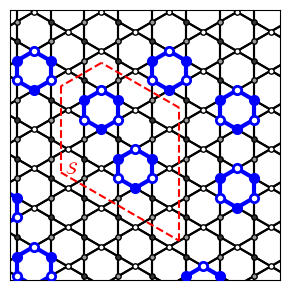

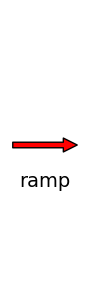

INFO:matplotlib.mathtext:Substituting symbol S from STIXNonUnicode


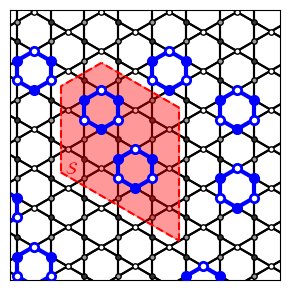

In [ ]:
# fig_lat, axes_lat = plt.subplots(1, 3, figsize = (7, 4), width_ratios = [5, 1, 5])
fig_lat1, ax_lat1 = plt.subplots(1, 1, figsize = (3, 3))
fig_arrow, ax_arrow = plt.subplots(1, 1, figsize = (1, 3))
fig_lat2, ax_lat2 = plt.subplots(1, 1, figsize = (3, 3))
all_figs = [fig_lat1, fig_arrow, fig_lat2]

# Arrow
ax_arrow.axis("off")
arrow_ramp = FancyArrowPatch(posA = [0, 0.5], posB = [1, 0.5], 
                             edgecolor = "black",
                             facecolor = "red",
                             mutation_scale = 20)
ax_arrow.add_patch(arrow_ramp)
ax_arrow.text(0.5, 0.4, "ramp", ha = "center", va = "top", fontsize = 14)

# for ax in [axes_lat[0]]:
for ax in [ax_lat1, ax_lat2]:
    my_tb_model.plot_H(ax = ax, H = H_total,
                    sublat_colors = ["#333333", "#999999", "#FFFFFF"],
                    sublat_kwargs = {"edgecolors": "black",
                                        "linewidths": 1})
    
    for pos in CLS_pos_list:
        plot_kag_CLS(ax, my_tb_model, pos)
    for pos1, pos2 in zip(sys_bd_list, sys_bd_roll):
        ax.plot([pos1[0], pos2[0]], [pos1[1], pos2[1]], linestyle = "--", color = "red")
    ax.text(*sys_txt_anchor, r"$\mathcal{S}$", ha = "left", va = "bottom",
            color = "red", fontsize = 12)

    ax.set_xlim(-7.1, -0.2)
    ax.set_ylim(3.9, 10.8)
    ax.set_xticks([])
    ax.set_yticks([])

# Add system offset patch
sys_poly_path = util.get_closed_polygon(sys_bd_list + [sys_bd_list[0]])
sys_poly_patch = patches.PathPatch(sys_poly_path, **sys_dict)
ax_lat2.add_patch(sys_poly_patch)

for fig in all_figs:
    fig.tight_layout()

thesis_fig_path_app = Path(r"C:\Users\ken92\Documents\Studies\E5\Theses\figures\flatband")
file_names = ["CLS_no_adia_t0.pdf", "CLS_no_adia_arrow.pdf", "CLS_no_adia_tf.pdf"]
for fig, str_fname in zip(all_figs, file_names):
    file_full_path = Path(thesis_fig_path_app, str_fname)
    fig.savefig(file_full_path, facecolor = "none", dpi = 300)#, bbox_inches='tight')